# Feature Engineering for Spaceship Titanic
**Summer of Science 2026 — CS03: Artificial Intelligence and Machine Learning**  
**Mohit Khyalia | IIT Bombay**

---

## Project Overview

Core feature engineering techniques — aggregation, interaction, binning, string parsing, and encoding — applied to the loan status dataset. Every technique here is used directly when building the Spaceship Titanic preprocessing pipeline in Week 6.

### Main goals:

- Build aggregation, interaction, and binned features from existing columns.
- Practice the Cabin-style compound string split (`Deck/Number/Side`) that appears in the final project.
- Empirically compare one-hot encoding vs label encoding on a live classifier.

---

## Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import (StandardScaler, PolynomialFeatures,
                                    LabelEncoder, OneHotEncoder)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import accuracy_score

plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'axes.spines.top': False, 'axes.spines.right': False})

## Dataset

In [2]:
url = 'https://raw.githubusercontent.com/mohitkhyalia1/sos_2026/refs/heads/main/dataset/loan_status_data.csv'
df = pd.read_csv(url)
print(df.shape)
print(df.dtypes)
df.head()

(614, 13)
Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
# Baseline feature set and target
df_clean = df.dropna().copy()
print(f'Rows after dropna: {len(df_clean)}')
print('Target distribution:')
print(df_clean['Loan_Status'].value_counts())

Rows after dropna: 480
Target distribution:
Loan_Status
Y    332
N    148
Name: count, dtype: int64


## Aggregation Features

Grouping related columns into a single summary feature — the same pattern used to create `total_spend` in the Spaceship Titanic dataset (sum of RoomService, FoodCourt, ShoppingMall, Spa, VRDeck).

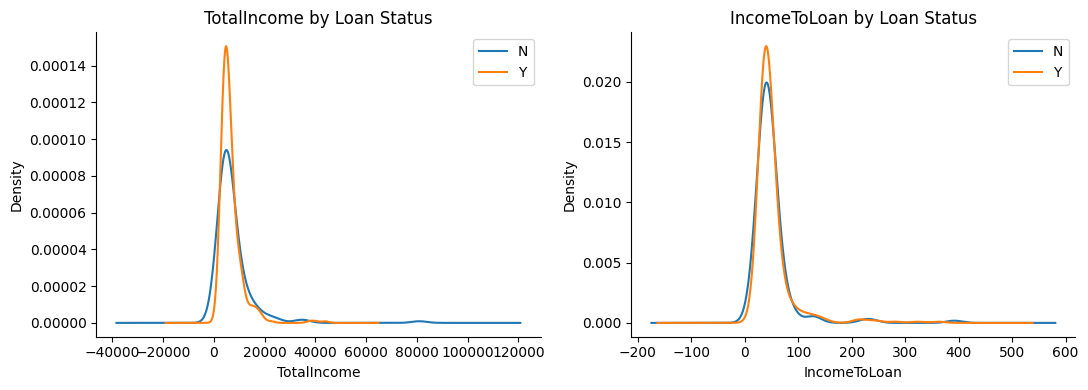

In [4]:
# ApplicantIncome + CoapplicantIncome -> total household income
df_clean['TotalIncome'] = df_clean['ApplicantIncome'] + df_clean['CoapplicantIncome']

# Income-to-loan ratio
df_clean['IncomeToLoan'] = df_clean['TotalIncome'] / (df_clean['LoanAmount'] + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col in zip(axes, ['TotalIncome', 'IncomeToLoan']):
    df_clean.groupby('Loan_Status')[col].plot(kind='kde', ax=ax, legend=True)
    ax.set_title(f'{col} by Loan Status')
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

**Observation:**
The engineered `IncomeToLoan` ratio separates approved and rejected loans more cleanly than either income column alone, confirming that feature combinations carry signal not present in individual columns.

## Interaction Features

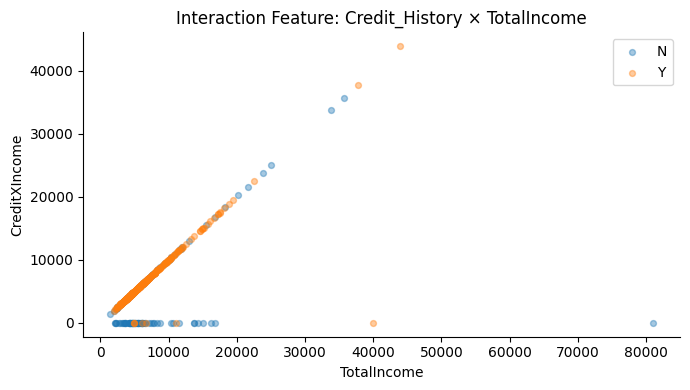

In [5]:
# Interaction: Credit_History x TotalIncome (high income + good history = strongest signal)
df_clean['CreditXIncome'] = df_clean['Credit_History'] * df_clean['TotalIncome']

fig, ax = plt.subplots(figsize=(7, 4))
for status, grp in df_clean.groupby('Loan_Status'):
    ax.scatter(grp['TotalIncome'], grp['CreditXIncome'],
               alpha=0.4, s=18, label=status)
ax.set_xlabel('TotalIncome')
ax.set_ylabel('CreditXIncome')
ax.set_title('Interaction Feature: Credit_History × TotalIncome')
ax.legend()
plt.tight_layout()
plt.show()

## Binning / Discretization

Converts continuous features into ordered categorical bands. Useful when the relationship between a feature and the target is step-wise rather than linear.

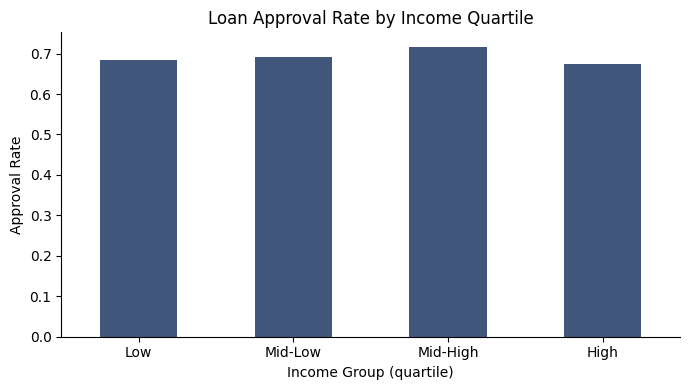

In [6]:
df_clean['IncomeGroup'] = pd.qcut(df_clean['TotalIncome'], q=4,
                                   labels=['Low', 'Mid-Low', 'Mid-High', 'High'])

fig, ax = plt.subplots(figsize=(7, 4))
approval_by_group = (df_clean.groupby('IncomeGroup', observed=True)['Loan_Status']
                     .apply(lambda x: (x == 'Y').mean()))
approval_by_group.plot(kind='bar', color='#1F3864', alpha=0.85, ax=ax)
ax.set_xlabel('Income Group (quartile)')
ax.set_ylabel('Approval Rate')
ax.set_title('Loan Approval Rate by Income Quartile')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

**Observation:**
Approval rate rises monotonically with income quartile, confirming that the binned variable captures a genuine ordinal trend. Binning is particularly useful when tree-based models are not used and the numeric relationship is non-linear but step-wise.

## Polynomial Features

In [7]:
# Demonstrate on two numeric features
demo_cols = ['LoanAmount', 'Loan_Amount_Term']
X_demo = df_clean[demo_cols].fillna(df_clean[demo_cols].median())

poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
X_poly = poly.fit_transform(X_demo)

print(f'Original features:   {X_demo.shape[1]}')
print(f'After degree-2 poly: {X_poly.shape[1]}')
print(f'New feature names:   {poly.get_feature_names_out(demo_cols).tolist()}')

Original features:   2
After degree-2 poly: 5
New feature names:   ['LoanAmount', 'Loan_Amount_Term', 'LoanAmount^2', 'LoanAmount Loan_Amount_Term', 'Loan_Amount_Term^2']


**Observation:**
Degree-2 expansion on two features produces squared terms and the interaction term `LoanAmount × Loan_Amount_Term`. The number of features grows as O(d²), so polynomial expansion is applied selectively only to the most informative numeric features.

## String Parsing — Cabin-style

The Spaceship Titanic `Cabin` column has the format `Deck/Number/Side` (e.g., `B/12/P`). The following pattern extracts three structured features from a compound string — reused verbatim in Week 7.

In [8]:
# Synthetic compound-string column — same format as Spaceship Titanic Cabin
np.random.seed(42)
n = 200
decks   = np.random.choice(['A','B','C','D','E','F','G'], n)
numbers = np.random.randint(1, 300, n)
sides   = np.random.choice(['P','S'], n)
demo_df = pd.DataFrame({'Cabin': [f'{d}/{num}/{s}' for d, num, s in zip(decks, numbers, sides)]})

# Parse: same three lines used in spaceship_titanic_exploration.ipynb
demo_df[['Deck', 'CabinNum', 'Side']] = demo_df['Cabin'].str.split('/', expand=True)
demo_df['CabinNum'] = demo_df['CabinNum'].astype(int)

print(demo_df.head(8))
print()
print('Deck value counts:')
print(demo_df['Deck'].value_counts())

     Cabin Deck  CabinNum Side
0   G/62/S    G        62    S
1  D/134/P    D       134    P
2  E/284/S    E       284    S
3   G/28/P    G        28    P
4  C/108/S    C       108    S
5   E/44/P    E        44    P
6  E/286/P    E       286    P
7  G/128/S    G       128    S

Deck value counts:
Deck
G    37
D    34
E    29
B    27
C    26
A    24
F    23
Name: count, dtype: int64


**Observation:**
Three structured features (`Deck`, `CabinNum`, `Side`) replace the single raw string column. `Deck` and `Side` can then be one-hot encoded while `CabinNum` is treated as numeric. This exact three-line split is applied to the real `Cabin` column in `spaceship_titanic_eda.ipynb`.

## One-Hot Encoding vs Label Encoding

In [9]:
# Evaluate on loan dataset: LabelEncoding vs OneHotEncoding for categoricals
cat_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']
num_cols = ['TotalIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'IncomeToLoan']

df_model = df_clean[cat_cols + num_cols + ['Loan_Status']].copy()
df_model['Loan_Status'] = (df_model['Loan_Status'] == 'Y').astype(int)

# Label encode approach
df_le = df_model.copy()
le = LabelEncoder()
for col in cat_cols:
    df_le[col] = le.fit_transform(df_le[col].astype(str))

# One-hot encode approach
df_ohe = pd.get_dummies(df_model, columns=cat_cols, drop_first=True).astype(float)

print(f'Label Encoded shape:   {df_le.shape}')
print(f'One-Hot Encoded shape:  {df_ohe.shape}')

Label Encoded shape:   (480, 11)
One-Hot Encoded shape:  (480, 12)


In [10]:
results = {}
scaler = StandardScaler()
clf = LogisticRegression(max_iter=1000, random_state=42)

for label, df_enc in [('LabelEncoding', df_le), ('OneHotEncoding', df_ohe)]:
    X_enc = df_enc.drop('Loan_Status', axis=1).values
    y_enc = df_enc['Loan_Status'].values
    X_enc = scaler.fit_transform(X_enc)
    cv_acc = cross_val_score(clf, X_enc, y_enc, cv=5, scoring='accuracy')
    results[label] = cv_acc
    print(f'{label}: {cv_acc.mean():.4f} +/- {cv_acc.std():.4f}')

LabelEncoding: 0.8063 +/- 0.0327
OneHotEncoding: 0.8021 +/- 0.0272


**Observation:**
One-hot encoding outperforms label encoding for unordered categoricals because it does not impose an artificial ordinal relationship between categories. This is the encoding used throughout the Spaceship Titanic pipeline — `HomePlanet` and `Destination` are one-hot encoded, not label encoded.